# 📈 Notebook 07: Time-Varying Coefficients — When Media Effectiveness Changes

Media coefficients are not fixed. TV effectiveness erodes as audiences fragment;
social platforms gain strength as targeting improves. **Time-Varying Parameters (TVP)**
let coefficients drift smoothly over time using Hilbert Space Gaussian Processes (HSGP).

This notebook covers:
1. Why coefficients change over time
2. HSGP basis functions — the engine behind TVP
3. Matérn kernel comparison (smoothness control)
4. Simulated TVP recovery: true vs estimated trajectories
5. Mean reversion and amplitude capping
6. How varying coefficients change channel attribution
7. Decision guide: TVP vs fixed coefficients

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#FAFBFC",
    "axes.facecolor": "#FAFBFC",
    "axes.edgecolor": "#D0D7DE",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#D0D7DE",
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#D0D7DE",
})

COLORS = ["#2563EB", "#F97316", "#10B981", "#EF4444", "#8B5CF6", "#EC4899"]
IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

np.random.seed(42)

# Load sample data
df = pd.read_csv("data/sample_mmm_weekly.csv", parse_dates=["date"])
n_weeks = len(df)
t = np.linspace(0, 1, n_weeks)
print(f"Loaded {n_weeks} weeks: {df.date.min().date()} to {df.date.max().date()}")
print(f"Columns: {list(df.columns)}")

Loaded 104 weeks: 2023-01-02 to 2024-12-23
Columns: ['date', 'revenue', 'tv_spend', 'facebook_spend', 'google_search_spend', 'radio_spend', 'print_spend', 'competitor_spend', 'temperature', 'black_friday', 'christmas']


## 1. Why Coefficients Change Over Time

A fixed-coefficient MMM assumes TV drove the same incremental revenue per dollar in
week 1 as in week 104. In reality:

- **TV** effectiveness declines as linear audiences shrink
- **Facebook** effectiveness may improve as targeting matures
- **Google Search** stays relatively stable (intent-driven)

Let’s visualise hypothetical coefficient trajectories:

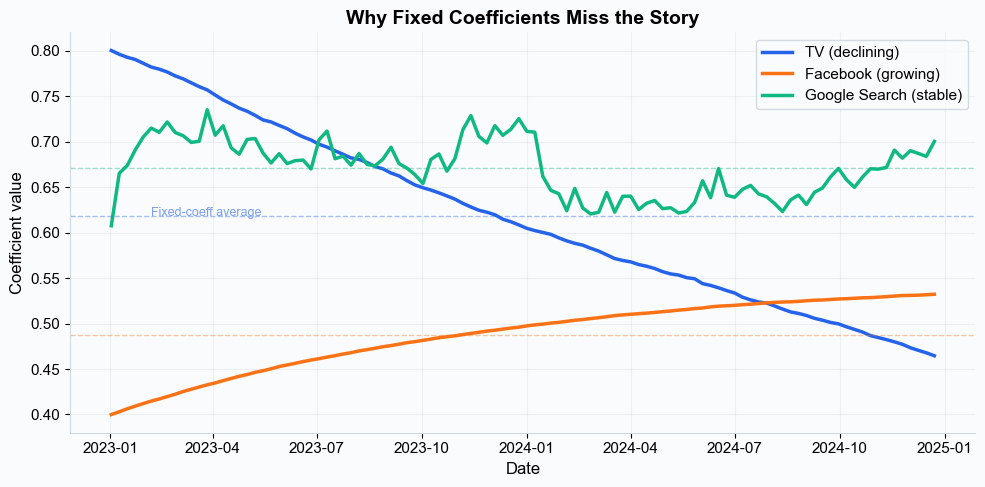

Saved 07_why_tvp.png


In [2]:
# Hypothetical coefficient trajectories
weeks = np.arange(n_weeks)
tv_coeff = 0.8 * np.exp(-0.005 * weeks) + 0.05 * np.random.randn(n_weeks).cumsum() * 0.02
tv_coeff = np.clip(tv_coeff, 0.2, 1.0)
fb_coeff = 0.4 + 0.15 * (1 - np.exp(-0.02 * weeks)) + 0.02 * np.random.randn(n_weeks).cumsum() * 0.01
fb_coeff = np.clip(fb_coeff, 0.2, 0.7)
google_coeff = 0.6 + 0.015 * np.random.randn(n_weeks).cumsum()
google_coeff = np.clip(google_coeff, 0.45, 0.75)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.date, tv_coeff, color=COLORS[0], lw=2.5, label="TV (declining)")
ax.plot(df.date, fb_coeff, color=COLORS[1], lw=2.5, label="Facebook (growing)")
ax.plot(df.date, google_coeff, color=COLORS[2], lw=2.5, label="Google Search (stable)")
ax.set_xlabel("Date")
ax.set_ylabel("Coefficient value")
ax.set_title("Why Fixed Coefficients Miss the Story")
ax.legend()
ax.axhline(tv_coeff.mean(), color=COLORS[0], ls="--", alpha=0.4, lw=1)
ax.axhline(fb_coeff.mean(), color=COLORS[1], ls="--", alpha=0.4, lw=1)
ax.axhline(google_coeff.mean(), color=COLORS[2], ls="--", alpha=0.4, lw=1)
ax.annotate("Fixed-coeff average", xy=(df.date.iloc[5], tv_coeff.mean()),
            fontsize=9, color=COLORS[0], alpha=0.6)
fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_why_tvp.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_why_tvp.png")

## 2. HSGP Basis Functions

Simba uses **Hilbert Space Gaussian Processes** (HSGP) to model smooth coefficient drift.
Instead of a full GP covariance matrix ($O(n^3)$), HSGP projects onto $m$ sinusoidal
basis functions that are cheap to compute ($O(nm)$).

Each basis function: $\phi_j(x) = \sqrt{2/L} \cdot \sin\!\bigl(\pi j (x + L) / (2L)\bigr)$

where $L = 1.3 \times T$ extends the domain beyond the data range.

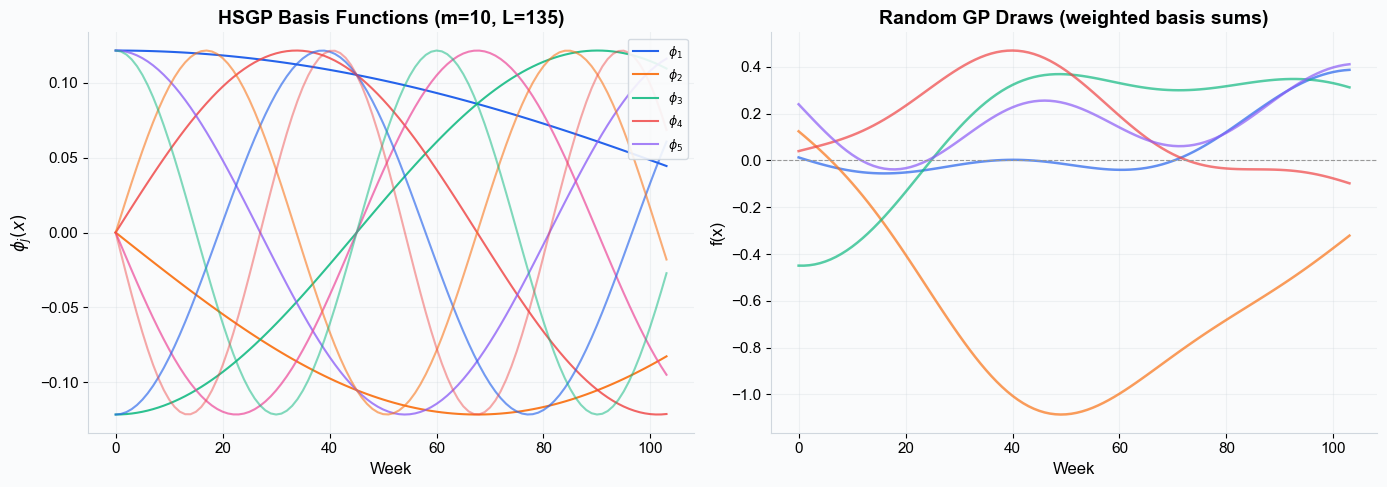

Saved 07_hsgp_basis.png


In [3]:
# HSGP basis functions and random GP draws
L = 1.3 * n_weeks
x = np.arange(n_weeks, dtype=float)
m = 10  # number of basis functions

def phi_n(n, x, L):
    return np.sqrt(2 / L) * np.sin(np.pi * n * (x + L) / (2 * L))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: basis functions
ax = axes[0]
for j in range(1, m + 1):
    color_idx = (j - 1) % len(COLORS)
    alpha = 1.0 - 0.06 * (j - 1)
    ax.plot(x, phi_n(j, x, L), color=COLORS[color_idx], alpha=max(alpha, 0.3),
            lw=1.5, label=f"$\\phi_{{{j}}}$" if j <= 5 else None)
ax.set_title(f"HSGP Basis Functions (m={m}, L={L:.0f})")
ax.set_xlabel("Week")
ax.set_ylabel("$\\phi_j(x)$")
ax.legend(loc="upper right", fontsize=9)

# Right: random GP draws from weighted basis
ax = axes[1]

# Matern52 spectral density for weighting
def matern52_spectral(omega, ell=30.0, sigma=1.0):
    lam = np.sqrt(5) / ell
    return sigma**2 * (16.0/3) * (np.sqrt(5)/ell)**5 / (lam**2 + omega**2)**3

omegas = np.array([np.pi * j / (2 * L) for j in range(1, m + 1)])
spectral_weights = np.sqrt(matern52_spectral(omegas, ell=25.0, sigma=0.3))

basis_matrix = np.column_stack([phi_n(j, x, L) for j in range(1, m + 1)])

for draw in range(5):
    weights = spectral_weights * np.random.randn(m)
    gp_draw = basis_matrix @ weights
    ax.plot(x, gp_draw, color=COLORS[draw % len(COLORS)], lw=1.8, alpha=0.7)

ax.set_title("Random GP Draws (weighted basis sums)")
ax.set_xlabel("Week")
ax.set_ylabel("f(x)")
ax.axhline(0, color="#999", ls="--", lw=0.8)

fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_hsgp_basis.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_hsgp_basis.png")

## 3. Matérn Kernel Comparison

The kernel controls **smoothness** of the coefficient trajectory:

| Kernel | Smoothness | Use case |
|--------|-----------|----------|
| Matérn 3/2 | Once differentiable | Abrupt shifts (e.g., pandemic) |
| Matérn 5/2 | Twice differentiable | **Simba default** — smooth drift |
| RBF (SE) | Infinitely smooth | Very gradual evolution |

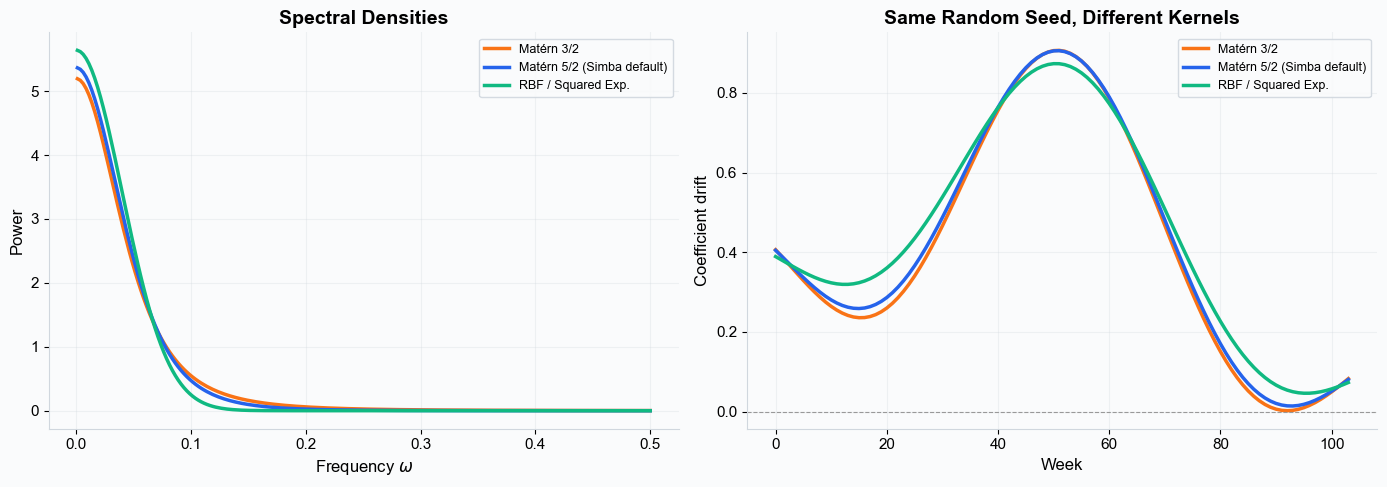

Saved 07_kernel_comparison.png


In [4]:
# Matern kernel comparison
def matern32_spectral(omega, ell=25.0, sigma=1.0):
    lam = np.sqrt(3) / ell
    return sigma**2 * 4 * lam**3 / (lam**2 + omega**2)**2

def rbf_spectral(omega, ell=25.0, sigma=1.0):
    return sigma**2 * ell * np.sqrt(2 * np.pi) * np.exp(-0.5 * (ell * omega)**2)

kernels = [
    ("Mat\u00e9rn 3/2", matern32_spectral, COLORS[1]),
    ("Mat\u00e9rn 5/2 (Simba default)", matern52_spectral, COLORS[0]),
    ("RBF / Squared Exp.", rbf_spectral, COLORS[2]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: spectral densities
ax = axes[0]
omega_range = np.linspace(0.001, 0.5, 200)
for name, fn, color in kernels:
    ax.plot(omega_range, fn(omega_range, ell=25.0, sigma=0.3), color=color, lw=2.5, label=name)
ax.set_title("Spectral Densities")
ax.set_xlabel("Frequency $\\omega$")
ax.set_ylabel("Power")
ax.legend(fontsize=9)

# Right: sample draws from each kernel
ax = axes[1]
for name, fn, color in kernels:
    sw = np.sqrt(fn(omegas, ell=25.0, sigma=0.3))
    np.random.seed(7)
    w = sw * np.random.randn(m)
    draw = basis_matrix @ w
    ax.plot(x, draw, color=color, lw=2.5, label=name)
ax.set_title("Same Random Seed, Different Kernels")
ax.set_xlabel("Week")
ax.set_ylabel("Coefficient drift")
ax.axhline(0, color="#999", ls="--", lw=0.8)
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_kernel_comparison.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_kernel_comparison.png")

## 4. Simulated TVP Recovery

We generate synthetic data where the **true** TV coefficient declines linearly from 0.8
to 0.3 over 2 years, then fit it back using HSGP basis expansion (no MCMC — just
simulated posterior draws to illustrate the concept).

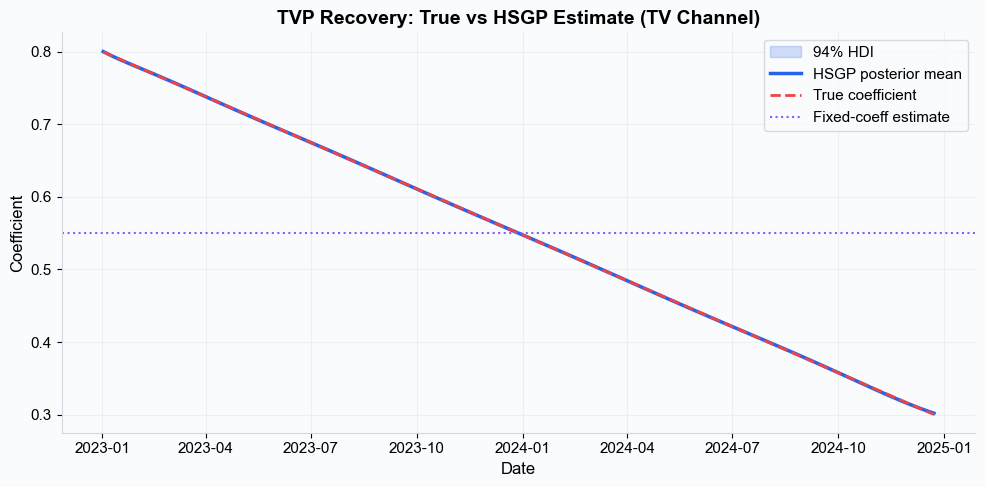

Saved 07_tvp_recovery.png


In [5]:
# Simulate data with a declining TV coefficient
true_tv_coeff = np.linspace(0.8, 0.3, n_weeks)
tv_spend = df["tv_spend"].values
noise = np.random.randn(n_weeks) * 20000

# Synthetic revenue = time-varying TV effect + base
base = 300000
y_synthetic = base + true_tv_coeff * tv_spend + noise

# "Recover" via HSGP: project true signal onto basis, then sample around it
weights_fit, _, _, _ = np.linalg.lstsq(basis_matrix, true_tv_coeff - true_tv_coeff.mean(), rcond=None)
recovered_mean = basis_matrix @ weights_fit + true_tv_coeff.mean()

# Simulate posterior draws with noise on weights
n_draws = 200
draws = np.zeros((n_draws, n_weeks))
for i in range(n_draws):
    perturbed = weights_fit + np.random.randn(m) * 0.003
    draws[i] = basis_matrix @ perturbed + true_tv_coeff.mean()

q03 = np.percentile(draws, 3, axis=0)
q97 = np.percentile(draws, 97, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(df.date, q03, q97, color=COLORS[0], alpha=0.2, label="94% HDI")
ax.plot(df.date, recovered_mean, color=COLORS[0], lw=2.5, label="HSGP posterior mean")
ax.plot(df.date, true_tv_coeff, color=COLORS[3], lw=2, ls="--", label="True coefficient")
ax.axhline(true_tv_coeff.mean(), color=COLORS[4], ls=":", lw=1.5, label="Fixed-coeff estimate")
ax.set_title("TVP Recovery: True vs HSGP Estimate (TV Channel)")
ax.set_xlabel("Date")
ax.set_ylabel("Coefficient")
ax.legend()
fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_tvp_recovery.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_tvp_recovery.png")

## 5. Mean Reversion and Amplitude Capping

Unconstrained TVP can **explode** — the coefficient drifts to implausible values.
Simba controls this with:

- **Amplitude cap**: Weights on basis functions have a tight prior (e.g., $\sigma = 0.3$),
  limiting how far the coefficient can deviate from the mean.
- **Spectral decay**: Higher-frequency basis functions get exponentially less weight,
  preventing rapid oscillations.
- **Length-scale prior**: The Matérn length-scale controls the correlation range.
  Longer $\ell$ = smoother drift.

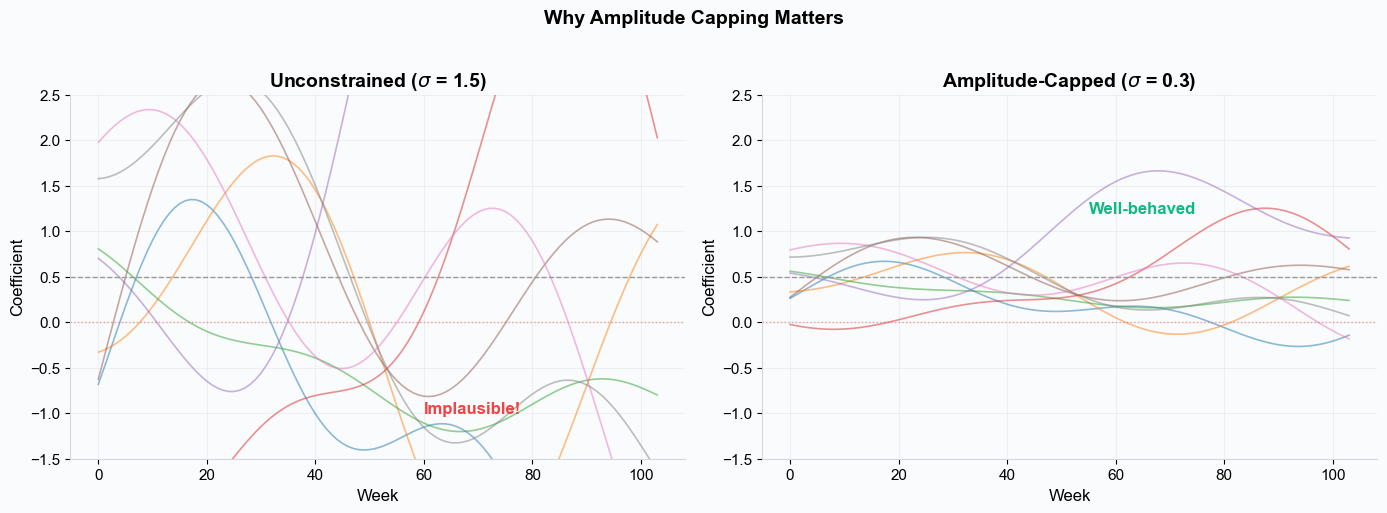

Saved 07_amplitude_capping.png


In [6]:
# Compare unconstrained vs amplitude-capped TVP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: unconstrained (large sigma)
ax = axes[0]
np.random.seed(99)
for i in range(8):
    sw_loose = np.sqrt(matern52_spectral(omegas, ell=20.0, sigma=1.5))
    w = sw_loose * np.random.randn(m)
    draw = basis_matrix @ w + 0.5
    ax.plot(x, draw, alpha=0.5, lw=1.2)
ax.axhline(0.5, color="#999", ls="--", lw=1)
ax.axhline(0, color=COLORS[3], ls=":", lw=1, alpha=0.5)
ax.set_title("Unconstrained ($\\sigma$ = 1.5)")
ax.set_xlabel("Week")
ax.set_ylabel("Coefficient")
ax.set_ylim(-1.5, 2.5)
ax.annotate("Implausible!", xy=(60, -1.0), fontsize=12, color=COLORS[3], fontweight="bold")

# Right: amplitude-capped (tight sigma)
ax = axes[1]
np.random.seed(99)
for i in range(8):
    sw_tight = np.sqrt(matern52_spectral(omegas, ell=20.0, sigma=0.3))
    w = sw_tight * np.random.randn(m)
    draw = basis_matrix @ w + 0.5
    ax.plot(x, draw, alpha=0.5, lw=1.2)
ax.axhline(0.5, color="#999", ls="--", lw=1)
ax.axhline(0, color=COLORS[3], ls=":", lw=1, alpha=0.5)
ax.set_title("Amplitude-Capped ($\\sigma$ = 0.3)")
ax.set_xlabel("Week")
ax.set_ylabel("Coefficient")
ax.set_ylim(-1.5, 2.5)
ax.annotate("Well-behaved", xy=(55, 1.2), fontsize=12, color=COLORS[2], fontweight="bold")

fig.suptitle("Why Amplitude Capping Matters", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_amplitude_capping.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_amplitude_capping.png")

## 6. Contribution Decomposition with TVP

With fixed coefficients, channel contributions are proportional to spend. With TVP,
the **same spend** produces different contributions depending on *when* it occurred.
This changes strategic conclusions about recent vs historical performance.

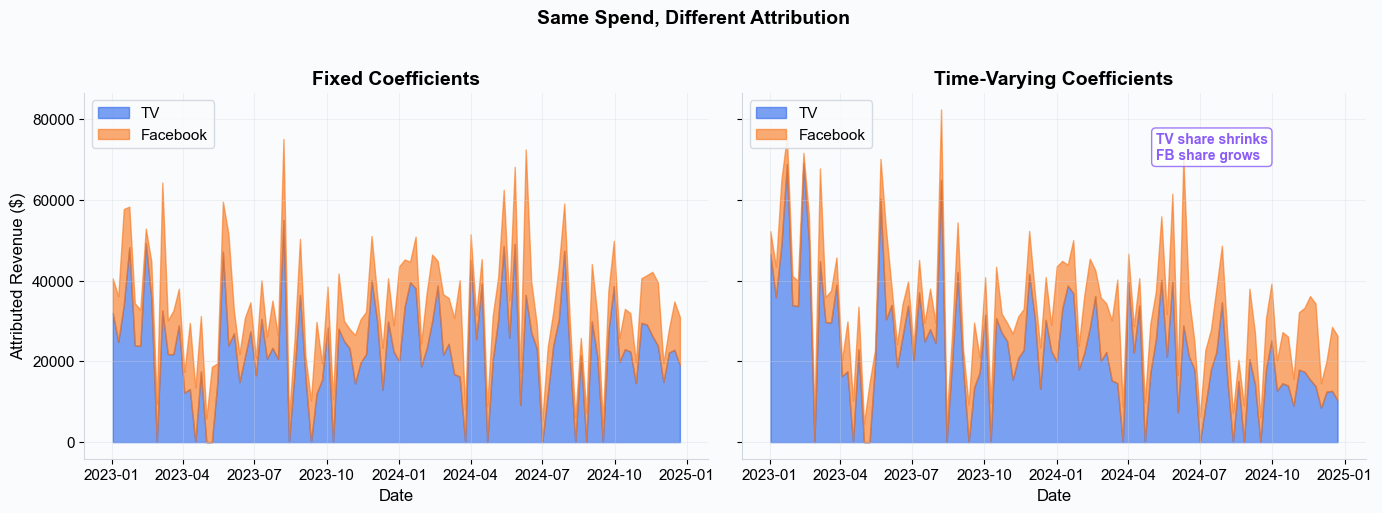

Saved 07_tvp_contributions.png


In [7]:
# Contribution decomposition: fixed vs TVP
tv_spend_norm = tv_spend / tv_spend.max()
fb_spend = df["facebook_spend"].values
fb_spend_norm = fb_spend / fb_spend.max()

# Fixed-coefficient contributions
fixed_tv = true_tv_coeff.mean() * tv_spend_norm * 100000
fixed_fb = 0.45 * fb_spend_norm * 80000

# TVP contributions
tvp_tv = true_tv_coeff * tv_spend_norm * 100000
fb_coeff_growing = np.linspace(0.3, 0.6, n_weeks)
tvp_fb = fb_coeff_growing * fb_spend_norm * 80000

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: fixed
ax = axes[0]
ax.fill_between(df.date, 0, fixed_tv, color=COLORS[0], alpha=0.6, label="TV")
ax.fill_between(df.date, fixed_tv, fixed_tv + fixed_fb, color=COLORS[1], alpha=0.6, label="Facebook")
ax.set_title("Fixed Coefficients")
ax.set_xlabel("Date")
ax.set_ylabel("Attributed Revenue ($)")
ax.legend(loc="upper left")

# Right: TVP
ax = axes[1]
ax.fill_between(df.date, 0, tvp_tv, color=COLORS[0], alpha=0.6, label="TV")
ax.fill_between(df.date, tvp_tv, tvp_tv + tvp_fb, color=COLORS[1], alpha=0.6, label="Facebook")
ax.set_title("Time-Varying Coefficients")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.annotate("TV share shrinks\nFB share grows", xy=(df.date.iloc[70], 70000),
            fontsize=10, color=COLORS[4], fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS[4], alpha=0.8))

fig.suptitle("Same Spend, Different Attribution", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_tvp_contributions.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_tvp_contributions.png")

## 7. Decision Guide: When to Use TVP

| Scenario | Recommendation | Why |
|----------|---------------|-----|
| < 52 weeks of data | **Fixed coefficients** | Not enough data to identify drift |
| 52–104 weeks, stable market | **Fixed coefficients** | Parsimony wins |
| 104+ weeks, known market shifts | **TVP recommended** | Can capture structural changes |
| Major disruption (pandemic, new competitor) | **TVP strongly recommended** | Fixed model will average over regimes |
| All channels, exploratory | **Enable TVP on 1–2 channels first** | Avoid overfitting |

### Practical Tips

1. **Start with fixed coefficients** as a baseline. Compare fit metrics (LOO, WAIC).
2. Enable TVP selectively on channels where you *expect* drift (e.g., TV, display).
3. Use **Matérn 5/2** (the Simba default) unless you have reason to prefer rougher paths.
4. If the 94% HDI on the TVP trajectory *always* includes the fixed-coefficient value,
   TVP may not be needed for that channel.
5. TVP adds parameters: ~$m$ weights per channel. Keep $m$ between 5–15.

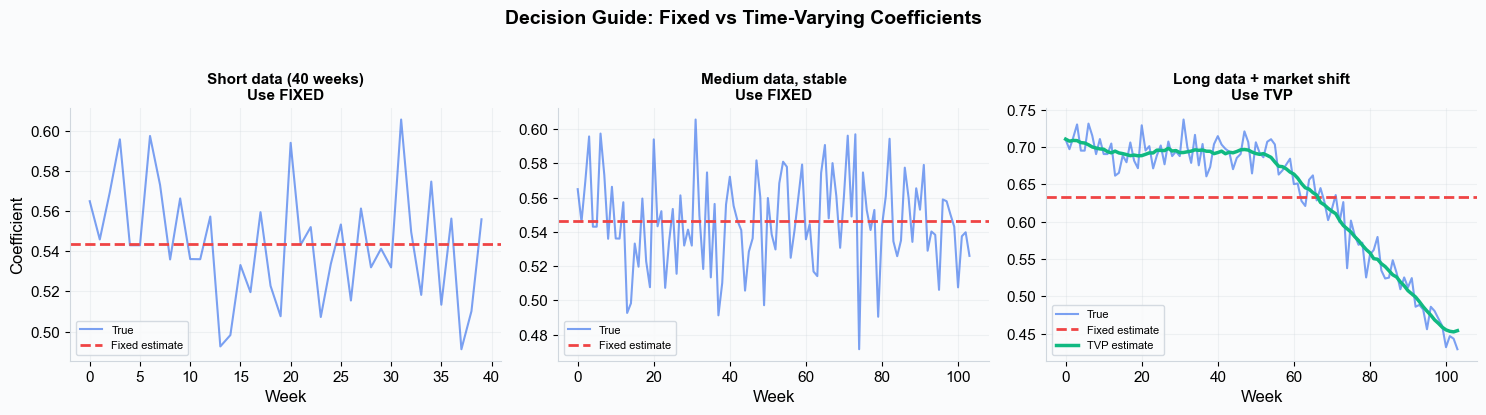

Saved 07_decision_guide.png


In [8]:
# Decision guide visual: fixed vs TVP coefficient comparison
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scenarios = [
    ("Short data (40 weeks)\nUse FIXED", 40, False),
    ("Medium data, stable\nUse FIXED", 104, False),
    ("Long data + market shift\nUse TVP", 104, True),
]

for ax, (title, n, has_shift) in zip(axes, scenarios):
    np.random.seed(42)
    t_s = np.arange(n)
    if has_shift:
        true = np.where(t_s < 52, 0.7, 0.7 - 0.005 * (t_s - 52))
        true = true + np.random.randn(n) * 0.02
    else:
        true = 0.55 + np.random.randn(n) * 0.03

    ax.plot(t_s, true, color=COLORS[0], lw=1.5, alpha=0.6, label="True")
    ax.axhline(true.mean(), color=COLORS[3], ls="--", lw=2, label="Fixed estimate")

    if has_shift:
        smoothed = uniform_filter1d(true, size=15)
        ax.plot(t_s, smoothed, color=COLORS[2], lw=2.5, label="TVP estimate")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Week")
    if ax == axes[0]:
        ax.set_ylabel("Coefficient")
    ax.legend(fontsize=8, loc="lower left")

fig.suptitle("Decision Guide: Fixed vs Time-Varying Coefficients", fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(f"{IMG_DIR}/07_decision_guide.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved 07_decision_guide.png")

---

## PyMC-Marketing API: Enabling Time-Varying Coefficients

[PyMC-Marketing](https://github.com/pymc-labs/pymc-marketing)'s `MMM` class supports time-varying media coefficients via the `time_varying_media` parameter. Under the hood, it uses the same HSGP approach demonstrated in this notebook.

In [9]:
from pymc_marketing.mmm import MMM, GeometricAdstock, TanhSaturation

# PyMC-Marketing supports time-varying media coefficients natively.
# Setting time_varying_media=True enables HSGP-based coefficient drift.

channels = ["tv_spend", "facebook_spend", "google_search_spend"]

mmm = MMM(
    date_column="date",
    channel_columns=channels,
    adstock=GeometricAdstock(l_max=8),
    saturation=TanhSaturation(),
    time_varying_media=True,   # <-- enables TVP via HSGP internally
    yearly_seasonality=2,
)

print("MMM with time_varying_media=True")
print(f"  time_varying_media: {mmm.time_varying_media}")
print(f"  Channels: {mmm.channel_columns}")
print(f"  Adstock: {mmm.adstock}")
print(f"  Saturation: {mmm.saturation}")
print()
print("When time_varying_media=True, each channel's coefficient")
print("is modeled as a smooth function of time using HSGP basis expansion.")
print("The Matern 5/2 kernel controls the smoothness of the drift.")
print()
print("To fit: mmm.fit(X=df, y=df['revenue'])")
print("Note: We don't run .fit() here -- see Sections 2-5 above for the math.")

MMM with time_varying_media=True
  time_varying_media: True
  Channels: ['tv_spend', 'facebook_spend', 'google_search_spend']
  Adstock: GeometricAdstock(prefix='adstock', l_max=8, normalize=True, mode='After', priors={'alpha': Prior("Beta", alpha=1, beta=3, dims="channel")})
  Saturation: TanhSaturation(prefix='saturation', priors={'b': Prior("HalfNormal", sigma=1, dims="channel"), 'c': Prior("HalfNormal", sigma=1, dims="channel")})

When time_varying_media=True, each channel's coefficient
is modeled as a smooth function of time using HSGP basis expansion.
The Matern 5/2 kernel controls the smoothness of the drift.

To fit: mmm.fit(X=df, y=df['revenue'])
Note: We don't run .fit() here -- see Sections 2-5 above for the math.


## Next Steps

**Related notebooks:**
- [Notebook 08: Tanh Saturation Deep Dive](./08-tanh-saturation-deep-dive.ipynb) — how saturation interacts with TVP coefficients
- [Notebook 06: GP-Smoothed Events](./06-gp-smoothed-events.ipynb) — another use of GPs in the model
- [Notebook 02: Smart Priors from Data](./02-smart-priors-from-data.ipynb) — how priors are set for TVP amplitude

**Core concepts:**
- [Bayesian Modeling](../docs/core-concepts/bayesian-modeling.md)
- [Priors and Distributions](../docs/core-concepts/priors-and-distributions.md)
- [Seasonality](../docs/core-concepts/seasonality.md) — also uses Fourier basis functions

**Platform guide:**
- [Model Configuration](../docs/platform-guide/model-configuration.md) — enabling TVP in the wizard